# Fourier Neural Operator for the Kuramoto-Sivashinsky Equation

This notebook implements a FNO for solving the Kuramoto-Sivashinsky equation

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
torch.manual_seed(2)
np.random.seed(2)


In [2]:
def load_training_data(params):
    """Load and process training data"""
    training_data = np.load('../../../data/ks_training.npy')
    t = np.linspace(0, params['T']/2, training_data.shape[0])  # First half of time domain
    x = np.linspace(0, params['L'], params['N'])
    
    # Create observation points
    X, T = np.meshgrid(x, t)
    X_train = np.hstack((X.flatten()[:, None], T.flatten()[:, None]))
    y_train = training_data.flatten()[:, None]
    
    return X_train, y_train, training_data

from torch.utils.data import Dataset
class MyDataset(Dataset):
    def __init__(self, data, target):
        self.data = torch.from_numpy(data).float()
        self.target = torch.from_numpy(target).float()
        #self.target = target
        
    def __getitem__(self, index):
        x = self.data[index]
        y = self.target[index]
        
        return {'x': x, 'y': y}
    
    def __len__(self):
        return len(self.data)

params = {
            'L': 30,
            'N': 2048,
            'dt': 0.5,
            'T': 100,
        }
X_train, y_train, training_data = load_training_data(params)

X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(y_train).float()

In [3]:
def load_testing_data(params):
    """Load and process testing data"""
    testing_data = np.load('../../../data/ks_truth.npy')
    t = np.linspace(params['T']/2, params['T'], testing_data.shape[0])  # First half of time domain
    x = np.linspace(0, params['L'], params['N'])
    
    # Create observation points
    X, T = np.meshgrid(x, t)
    X_train = np.hstack((X.flatten()[:, None], T.flatten()[:, None]))
    print(testing_data.shape)
    y_train = testing_data.flatten()[:, None]
    
    return X_train, y_train, testing_data


X_test, y_test, testing_data = load_testing_data(params)
X_test = torch.from_numpy(X_test).float()
y_test = torch.from_numpy(y_test).float()


grid_size = 1/params['N']
time_steps = ((params['T']+params['dt'])//2) // params['dt']
time_steps = 100


(100, 2048)


In [4]:
import numpy as np
import torch
from sklearn.preprocessing import MinMaxScaler
print(X_train[:10])
# Example dimensions
N, T, H = 1, time_steps, params['N']  # 100 samples, 100 time steps, 64 spatial points
x = np.linspace(0, 30, H)  # spatial grid (1D)
# Simulated data: shape (N, T+1, H)
u_all = y_train.view(N, H, T+1).permute(0, 2, 1)  # (N, T+1, H)
print(u_all.shape)
# Build input-output pairs
input_list = []
output_list = []
print(training_data.shape)
u_all = training_data.reshape((1, T+1, H))
# This functions creates couples of u_t and u_{t+1} for each time step
for i in range(T):
    u_t = u_all[:, i, :]      # (N, H)
    u_tp1 = u_all[:, i+1, :]  # (N, H)
    
    # Repeat x for all samples
    x_repeat = np.tile(x, (N, 1))  # (N, H)
    # Combine as 2 input channels: [u_t, x]
    input_step = np.stack([u_t, x_repeat], axis=1)  # (N, 2, H)
    #input_step = u_t[:, np.newaxis, :]  # (N, 1, H)
    output_step = u_tp1[:, np.newaxis, :]           # (N, 1, H)

    input_list.append(input_step)
    output_list.append(output_step)

# Stack over all time steps
input_tensor = np.concatenate(input_list, axis=0)    # (N*T, 2, H)
output_tensor = np.concatenate(output_list, axis=0)  # (N*T, 1, H)

# Convert to torch tensors
input_tensor = torch.tensor(input_tensor, dtype=torch.float32)
output_tensor = torch.tensor(output_tensor, dtype=torch.float32)

input_tensor_start = input_tensor.clone()
output_tensor_start = output_tensor.clone()
# Apply normalization

# Normalize input_tensor and output_tensor
scaler_input = MinMaxScaler(feature_range=(0, 1))
scaler_output = MinMaxScaler(feature_range=(0, 1))

# Reshape for normalization
input_tensor_reshaped = input_tensor.view(input_tensor.shape[0], -1).numpy()
output_tensor_reshaped = output_tensor.view(output_tensor.shape[0], -1).numpy()

# Fit and transform
input_tensor_normalized = scaler_input.fit_transform(input_tensor_reshaped)
output_tensor_normalized = scaler_output.fit_transform(output_tensor_reshaped)

# Reshape back to original dimensions
input_tensor = torch.tensor(input_tensor_normalized).view_as(input_tensor)
output_tensor = torch.tensor(output_tensor_normalized).view_as(output_tensor)

tensor([[0.0000, 0.0000],
        [0.0147, 0.0000],
        [0.0293, 0.0000],
        [0.0440, 0.0000],
        [0.0586, 0.0000],
        [0.0733, 0.0000],
        [0.0879, 0.0000],
        [0.1026, 0.0000],
        [0.1172, 0.0000],
        [0.1319, 0.0000]])
torch.Size([1, 101, 2048])
(101, 2048)


In [5]:
print(input_tensor.shape)

torch.Size([100, 2, 2048])


In [6]:
from neuralop.models import FNO1d
from neuralop.utils import count_model_params
from neuralop.models import FNO
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

from neuralop.models import FNO1d

# Create FNO1d model
model = FNO1d(n_modes_height=32,
             in_channels=2,
             out_channels=1,
             hidden_channels=32,
             projection_channel_ratio=1)
model = model.to(device)

n_params = count_model_params(model)
print(f'\nOur model has {n_params} parameters.')
# Forward pass
print(input_tensor.shape)
output_pred = model(input_tensor.to(device))  # (N*T, 1, H)
loss = torch.nn.functional.mse_loss(output_pred, output_tensor.to(device))


Our model has 152417 parameters.
torch.Size([100, 2, 2048])


In [7]:
from torch.optim import AdamW
optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-6)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, verbose=True)


c:\Users\aless\anaconda3\envs\MLgeneric\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [8]:
# Creating the losses
from neuralop.losses import LpLoss, H1Loss
l2loss = LpLoss(d=2, p=2)
h1loss = H1Loss(d=2)

train_loss = h1loss
eval_losses={'h1': h1loss, 'l2': l2loss}

In [9]:
from torch.utils.data import TensorDataset, DataLoader

# Assuming you have these already
# input_tensor: (N*T, in_channels, H)
# output_tensor: (N*T, out_channels, H)

dataset = TensorDataset(input_tensor, output_tensor)
train_loader = DataLoader(dataset, batch_size=16, shuffle=True)

In [10]:
import torch
from torch import nn
loss_fun = torch.nn.MSELoss()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

n_epochs = 1000
# Trainint loop
for epoch in range(n_epochs):
    model.train()
    total_loss = 0.0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        pred = model(x_batch)
        loss = loss_fun(pred, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{n_epochs}, Loss: {avg_loss:.6f}")

Epoch 1/1000, Loss: 0.133584
Epoch 2/1000, Loss: 0.063085
Epoch 3/1000, Loss: 0.061993
Epoch 4/1000, Loss: 0.053677
Epoch 5/1000, Loss: 0.046454
Epoch 6/1000, Loss: 0.031590
Epoch 7/1000, Loss: 0.014839
Epoch 8/1000, Loss: 0.009686
Epoch 9/1000, Loss: 0.006869
Epoch 10/1000, Loss: 0.004484
Epoch 11/1000, Loss: 0.003632
Epoch 12/1000, Loss: 0.003184
Epoch 13/1000, Loss: 0.002735
Epoch 14/1000, Loss: 0.002545
Epoch 15/1000, Loss: 0.002423
Epoch 16/1000, Loss: 0.002156
Epoch 17/1000, Loss: 0.001978
Epoch 18/1000, Loss: 0.002086
Epoch 19/1000, Loss: 0.001949
Epoch 20/1000, Loss: 0.001803
Epoch 21/1000, Loss: 0.001553
Epoch 22/1000, Loss: 0.001528
Epoch 23/1000, Loss: 0.001363
Epoch 24/1000, Loss: 0.001281
Epoch 25/1000, Loss: 0.001191
Epoch 26/1000, Loss: 0.001019
Epoch 27/1000, Loss: 0.000857
Epoch 28/1000, Loss: 0.000718
Epoch 29/1000, Loss: 0.000571
Epoch 30/1000, Loss: 0.000489
Epoch 31/1000, Loss: 0.000457
Epoch 32/1000, Loss: 0.000361
Epoch 33/1000, Loss: 0.000351
Epoch 34/1000, Loss

In [11]:
# Save
torch.save(model.state_dict(), "fno1d_model.pth")

# Load later
model.load_state_dict(torch.load("fno1d_model.pth"))
model.eval()

C:\Users\aless\AppData\Local\Temp\ipykernel_23716\493918379.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("fno1d_model.pth"))


FNO1d(
  (positional_embedding): GridEmbeddingND()
  (fno_blocks): FNOBlocks(
    (convs): ModuleList(
      (0-3): 4 x SpectralConv(
        (weight): DenseTensor(shape=torch.Size([32, 32, 17]), rank=None)
      )
    )
    (fno_skips): ModuleList(
      (0-3): 4 x Flattened1dConv(
        (conv): Conv1d(32, 32, kernel_size=(1,), stride=(1,), bias=False)
      )
    )
    (channel_mlp): ModuleList(
      (0-3): 4 x ChannelMLP(
        (fcs): ModuleList(
          (0): Conv1d(32, 16, kernel_size=(1,), stride=(1,))
          (1): Conv1d(16, 32, kernel_size=(1,), stride=(1,))
        )
      )
    )
    (channel_mlp_skips): ModuleList(
      (0-3): 4 x SoftGating()
    )
  )
  (lifting): ChannelMLP(
    (fcs): ModuleList(
      (0): Conv1d(3, 64, kernel_size=(1,), stride=(1,))
      (1): Conv1d(64, 32, kernel_size=(1,), stride=(1,))
    )
  )
  (projection): ChannelMLP(
    (fcs): ModuleList(
      (0): Conv1d(32, 64, kernel_size=(1,), stride=(1,))
      (1): Conv1d(64, 1, kernel_size=(1

In [12]:
u_t =  output_tensor_start[-1].reshape((1,1,-1)) # Last knowntrainin state (N, H)
print(u_t.shape)
x = np.tile(x, (N, 1))  # Repeat x for all samples (N, H)
inp = np.stack([u_t.squeeze(1), x], axis=1)  # (N, 2, H)

outputs = []
num_steps = 100  # Number of prediction steps
for t in range(num_steps):
    x_repeat = np.tile(x, (N, 1))  # Repeat x for all samples (N, H)
    inp = np.stack([u_t.squeeze(1), x_repeat], axis=1)  # (N, 2, H)
    inp_reshaped = inp.reshape(inp.shape[0], -1)  # Flatten inp for normalization
    inp_normalized = scaler_input.transform(inp_reshaped)  # Normalize inp
    inp = inp_normalized.reshape(inp.shape)  # Reshape back to original dimensions
    inp = torch.tensor(inp, dtype=torch.float32).to(device)  # (1, 2, H)
    u_tp1 = model(inp)
    u_t = u_tp1.clone().cpu().detach().numpy()  # feed prediction back in
    # Reverse normalization
    u_t_reshaped = u_t.reshape(u_t.shape[0], -1)  # Flatten for inverse transform
    u_t_denormalized = scaler_output.inverse_transform(u_t_reshaped)  # Denormalize
    u_t = u_t_denormalized.reshape(u_t.shape)  # Reshape back to original dimensions
    outputs.append(u_t.squeeze(1))  # Append the prediction

torch.Size([1, 1, 2048])


In [13]:
outputs_np = np.array(outputs).squeeze(1)  # (num_steps, H)
print(outputs_np.shape)
#outputs_np = outputs_np.reshape(-1, 1)  # Reshape to (num_steps*H, 1)
#print(outputs_np.shape)
#print(outputs_np.shape)
print(testing_data.shape)
#print(loss_fun(torch.tensor(outputs_np), torch.tensor(testing_data)).item())

(100, 2048)
(100, 2048)


## Visualization Function

Define a function to visualize the solution.

In [14]:
def plot_solution(x, t, u):
    plt.figure(figsize=(10, 6))
    X, T = np.meshgrid(x, t)
    plt.pcolormesh(X, T, u, shading='auto')
    plt.colorbar(label='u(x,t)')
    plt.xlabel('x')
    plt.ylabel('t')
    plt.title('Kuramoto-Sivashinsky Solution')
    plt.show()

## Training and Prediction

Now we'll train the model and generate predictions. You can choose to load a pretrained model or train from scratch.

## Visualize Training History

## Generate and Plot Predictions

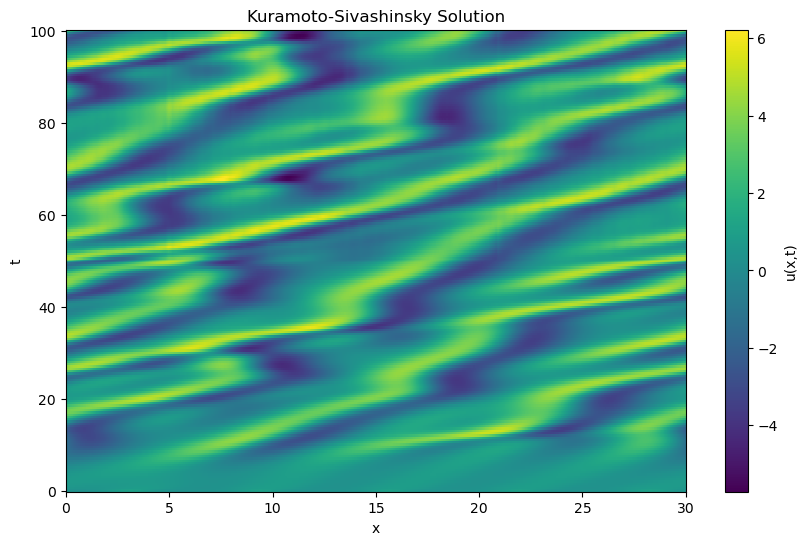

In [15]:
# Define spatial and temporal grids
x = np.linspace(0, params['L'], params['N'])
t_initial = np.linspace(0, params['T']/2, training_data.shape[0])
t_predicted = np.linspace(params['T']/2, params['T'], num_steps)

# Combine initial and predicted data
u_combined = np.vstack((training_data, outputs_np))
t_combined = np.concatenate((t_initial, t_predicted))

# Plot the combined solution
plot_solution(x, t_combined, u_combined)

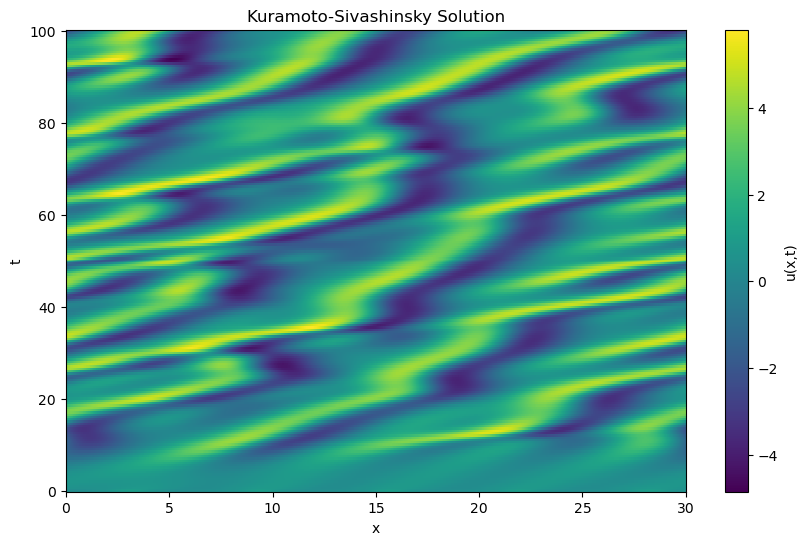

In [16]:
# Define spatial and temporal grids
x = np.linspace(0, params['L'], params['N'])
t_initial = np.linspace(0, params['T']/2, training_data.shape[0])
t_predicted = np.linspace(params['T']/2, params['T'], num_steps)

# Combine initial and predicted data
u_combined_true = np.vstack((training_data, testing_data))
t_combined = np.concatenate((t_initial, t_predicted))

# Plot the combined solution
plot_solution(x, t_combined, u_combined_true)

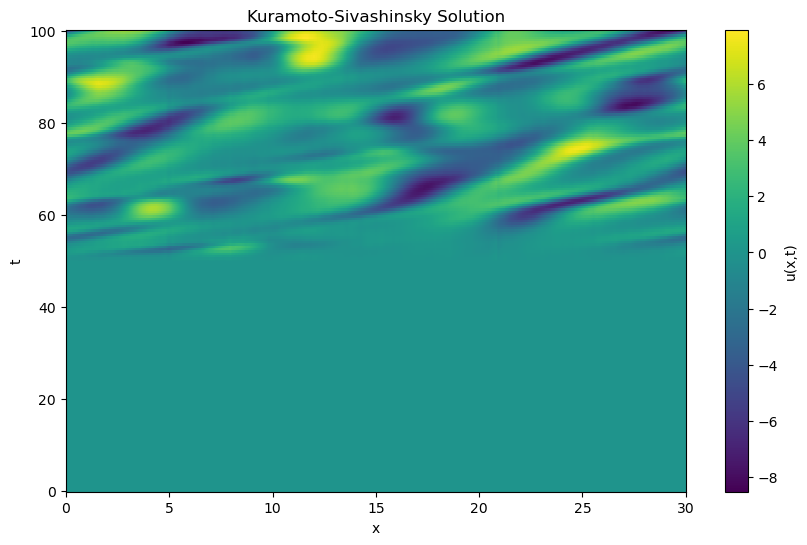

In [17]:
# Compute the difference
difference = u_combined_true - u_combined

# Plot the difference
plot_solution(x, t_combined, difference)

## Save Predictions

In [18]:
print(testing_data.shape)
print(outputs_np.shape)

(100, 2048)
(100, 2048)


In [19]:
# Save the prediction
TEAM_FOLDER = "../"
os.makedirs(TEAM_FOLDER, exist_ok=True)

params['num_steps'] = num_steps
PREDICTION_FILE = os.path.join(TEAM_FOLDER, "ks_prediction.npy")
np.save(PREDICTION_FILE, outputs_np)

print(f"Saved prediction to: {PREDICTION_FILE}")
print(f"Prediction shape: {outputs_np.shape}")

Saved prediction to: ../ks_prediction.npy
Prediction shape: (100, 2048)


In [20]:
print(loss_fun(torch.tensor(outputs_np), torch.tensor(testing_data)).item())

6.54712249977079


In [21]:
import numpy as np
import matplotlib.pyplot as plt

k=20 # number of snapshots to test for short time and long time
modes = 20 # Need modes strictly less than m/2

# SCORING FOR SHORT-TIME AND LONG-TIME FORECASTS
def scoring_ks(truth, prediction, k, modes):
    '''produce long-time and short-time error scores.'''
    [m,n]=truth.shape
    Est = np.linalg.norm(truth[:,0:k]-prediction[:,0:k],2)/np.linalg.norm(truth[:,0:k],2)

    m2 = 2*modes+1
    Pt = np.empty((m2,0))
    Pp = np.empty((m2,0))

    # LONG TIME:  Compute least-square fit to power spectra
    for j in range(1, k+1):
        P_truth = np.multiply(np.abs(np.fft.fft(truth[:, n-j])), np.abs(np.fft.fft(truth[:, n-j])))
        P_prediction = np.multiply(np.abs(np.fft.fft(prediction[:, n-j])), np.abs(np.fft.fft(prediction[:, n-j])))
        Pt3 = np.fft.fftshift(P_truth)
        Pp3 = np.fft.fftshift(P_prediction)
        Ptnew = Pt3[int(m/2)-modes:int(m/2)+modes+1]
        Ppnew = Pp3[int(m/2)-modes:int(m/2)+modes+1]  # Fixed the variable name
    
        Pt = np.column_stack((Pt, np.log(Ptnew)))
        Pp = np.column_stack((Pp, np.log(Ppnew)))
    
    Elt = np.linalg.norm(Pt-Pp,2)/np.linalg.norm(Pt,2)
    
    E1 = 100*(1-Est)
    E2 = 100*(1-Elt)

    if np.isnan(E1):
        E1 = -np.inf
    if np.isnan(E2):
        E2 = -np.inf
    
    
    return E1, E2

DATA_FOLDER = "..\\..\\..\\data"
TEAM_FOLDER = "..\\"
TRUTH_FILE = os.path.join(DATA_FOLDER, "ks_truth.npy")
PREDICTION_FILE = os.path.join(TEAM_FOLDER, "ks_prediction.npy")

truth = np.load(TRUTH_FILE)
prediction = np.load(PREDICTION_FILE)
E1, E2 = scoring_ks(truth, prediction, k, modes)
print(E1)
print(E2)

13.460175644408556
75.82159047454746
